# Questão 2

### 2. a

Pela definição, $L_X(p) = (p(x_1), p(x_2),..., p(x_m)) \in \mathbb{R}^m$. Chame $b = L_X(p)$. 

$R_{X,d}(b)$ é o polinômio $q \in P_d$ que minimiza: $$||L_X(q) - b||_{2}^2 = \sum_{i=1}^m (q(x_i)-b_i)^2$$

Substituindo $q=p$: $$\sum_{i=1}^m (p(x_i) - b)^2 = \sum_{i=1}^m (p(x_i) - p(x_i))^2 = 0$$

O menor valor possível de uma soma de quadrados é 0, portanto, p é a solução do problema de mínimos quadrados.

Como $R_{X,d}(L_X(p)) = p$ concluímos que $$R_{X,d} \circ L_X = Id_{P_d}$$

### 2. b

Seja $v_1 = R_{X,d}(b_1)$ e $v_2 = R_{X,d}(b_2) \Rightarrow V^*Vv_1 = V^*b_1$ e $V^*Vv_2 = V^*b_2$.

$R_{X,d}(\alpha b_1 + \beta b_2) = v' \Leftrightarrow V^*Vv' = V^*(\alpha b_1 + \beta b_2)$

Como $V$ tem posto cheio, temos que $V^*V$ é invertível, o que faz com que a solução seja única.

Se $v' = \alpha v_1 + \beta v_2 \Rightarrow V^*Vv' = V^*V(\alpha v_1 + \beta v_2) = \alpha V^*Vv_1 + \beta V^*Vv_2 = V^*(\alpha b_1 + \beta b_2)$

Portanto concluímos que $R_{X,d}(\alpha b_1 + \beta b_2) = \alpha R_{X,d}(b_1) + \beta R_{X,d}(b_2)$

Logo $R_{X,d}$ é uma transformação linear.

### 2. c

Para calcular a matriz de $R_{X,d}:\mathbb{R}^m \rightarrow P_d$, usamos a base canônica ${e_1, e_2,..., e_m}$ de $\mathbb{R}^m$ e a base canônica ${1, x,..., x^d}$ de $P_d$. A j-ésima coluna da matriz é obtida calculando $R_{X,d}(e_j)$, ou seja, o polinômio $p \in P_d$ que minimiza $||L_X(p) - e_j||_{2}^2$. Isso é exatamente o polinômio que vale 1 no ponto $x_j$ e 0 em todos os outros pontos de X, logo, $p(x_i) = \delta_{i,j}$. Esse é exatamente o polinômio interpolador de Lagrange.

Portanto, a matriz de $R_{X,d}$ é a matriz $(d+1)\times m$ cujas colunas são os coeficientes dos polinômios interpoladores de Lagrange $p_1,..., p_m$ escritos na base canônica. Se $p_j(x) = a_{0}^{(j)} + a_{1}^{(j)}x + ... + a_{d}^{(j)}x^d$, então: 
$$ [R_{X,d}] =
\begin{pmatrix}
a_0^{(1)} & a_0^{(2)} & \cdots & a_0^{(m)} \\
a_1^{(1)} & a_1^{(2)} & \cdots & a_1^{(m)} \\
\vdots    & \vdots    & \ddots & \vdots    \\
a_d^{(1)} & a_d^{(2)} & \cdots & a_d^{(m)}
\end{pmatrix} $$

De forma equivalente, como a matriz de $L_X$ na base canônica é a matriz de Vondermonde $V$ de tamanho $m \times (d+1)$, a solução de mínimos quadrados é dada pela pseudoinversa $[R_{X,d}] = (V^{T}V)^{-1}V^T$.

### 2. d

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def canonic_Lx_test_fixing_m(m: int, ax=None) -> None:
    X = np.linspace(-1,1,m)
    x = np.linspace(2,m,m-1)
    y = []
    for d in range(1, m):
        V = np.vander(X, N=d+1, increasing=True)
        c = np.linalg.cond(V)
        y.append(c)
    ax.plot(x, y, label="canônica")
    ax.set_xlabel("d")
    ax.set_ylabel("cond")
    ax.set_yscale("log")


def canonic_Lx_test_fixing_d(d:int, max_m:int, ax=None) -> None:
    x = []
    y = []
    for m in range(d+1, max_m+1):
        X = np.linspace(-1,1,m)
        V = np.vander(X,N=d+1,increasing=True)
        c = np.linalg.cond(V)
        x.append(m)
        y.append(c)
    ax.plot(x, y, label="canônica")
    ax.set_xlabel("m")
    ax.set_ylabel("cond")

def canonic_Rx_test_fixing_m(m: int, ax=None) -> None:
    X = np.linspace(-1,1,m)
    x = np.linspace(2,m,m-1)
    y = []
    for d in range(1, m):
        V = np.vander(X, N=d+1, increasing=True)
        V = np.linalg.pinv(V)
        c = np.linalg.cond(V)
        y.append(c)
    ax.plot(x, y, label="canônica")
    ax.set_xlabel("d")
    ax.set_ylabel("cond")
    ax.set_yscale("log")


def canonic_Rx_test_fixing_d(d:int, max_m:int, ax=None) -> None:
    x = []
    y = []
    for m in range(d+1, max_m+1):
        X = np.linspace(-1,1,m)
        V = np.vander(X,N=d+1,increasing=True)
        V = np.linalg.pinv(V)
        c = np.linalg.cond(V)
        x.append(m)
        y.append(c)
    ax.plot(x, y, label="canônica")
    ax.set_xlabel("m")
    ax.set_ylabel("cond")

Nessa questão vamos utilizar o conjunto de pontos $X$ = np.linspace[$-1,1,m$].

A escolha é bem natural por 2 motivos:

1)  A questão 3 já pede pra utilizar X = linspace[$-1,1,m$].

2) Manter os pontos no intervalo [$-1,1$] evita que as colunas de $x^d$ explodam, assim, o crescimento de $\kappa(V)$ reflete o a má condição da base canônica.

Text(0.5, 1.0, 'Rx fixando m')

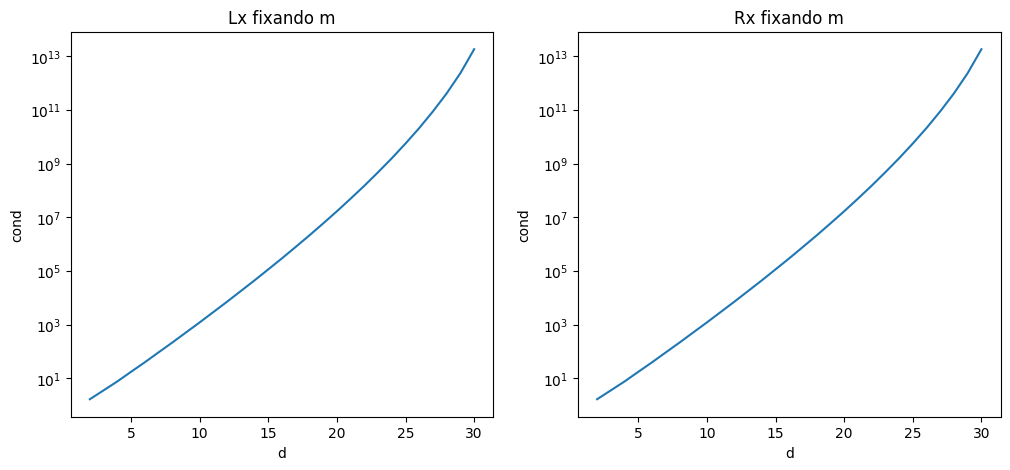

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

canonic_Lx_test_fixing_m(30, ax=ax1)
ax1.set_title("Lx fixando m")

canonic_Rx_test_fixing_m(30, ax=ax2)
ax2.set_title("Rx fixando m")

Text(0.5, 1.0, 'Rx fixando d')

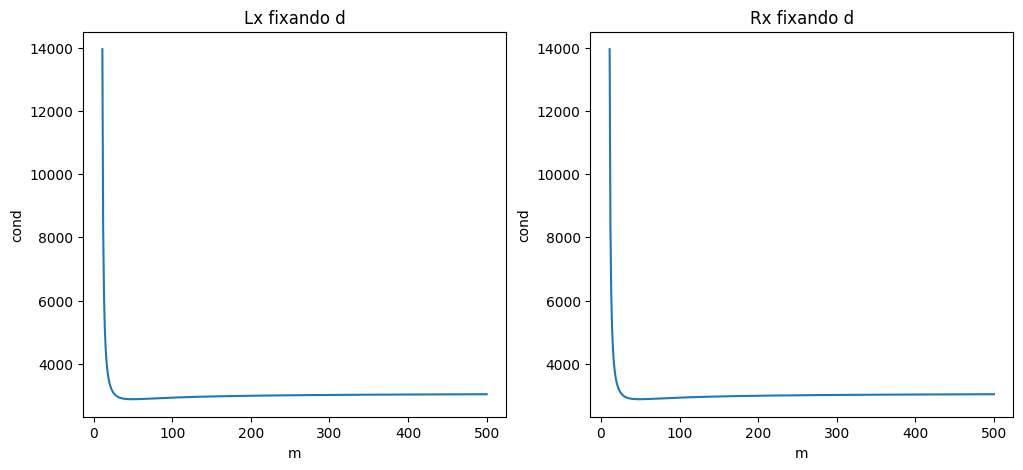

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

canonic_Lx_test_fixing_d(10, 500, ax=ax1)
ax1.set_title("Lx fixando d")

canonic_Rx_test_fixing_d(10, 500, ax=ax2)
ax2.set_title("Rx fixando d")

Como podemos ver, aumentar $d$ com $m$ fixo aumenta drasticamente o condicionamento da matriz, enquanto aumentar $m$ fixando $d$ estabiliza o condicionamento da matriz.

### 2. e

In [ ]:
def lagrange_basis(X, d):
    m = len(X)
    indices = np.round(np.linspace(0, m-1, d+1)).astype(int)
    X = X[indices]
    basis = []

    for i in range(d+1):
        p = np.poly1d([1])

        for j in range(d+1):
            if j != i:
                p *= np.poly1d((1, - X[j])) / (X[i] - X[j])
        basis.append(p)

    return basis

def lagrange_L_X(X, d):
    m = len(X)
    basis = lagrange_basis(X, d)
    M = np.zeros((m, d+1))
    for j in range(d+1):
        for i in range(m):
            M[i,j] = basis[j](X[i])
    return M

def lagrange_R_Xd(X, d):
    Lx = lagrange_L_X(X, d)
    return np.linalg.pinv(Lx)

def lagrange_Lx_test_fixing_m(m: int, ax=None) -> None:
    X = np.linspace(-1,1,m)
    x = np.linspace(2,m,m-1)
    y = []
    for d in range(1, m):
        M = lagrange_L_X(X, d)
        c = np.linalg.cond(M)
        y.append(c)
    ax.plot(x, y, label="lagrange")
    ax.set_xlabel("d")
    ax.set_ylabel("cond")
    ax.set_yscale("log")


def lagrange_Lx_test_fixing_d(d:int, max_m:int, ax=None) -> None:
    x = []
    y = []
    for m in range(d+1, max_m+1):
        X = np.linspace(-1,1,m)
        M = lagrange_L_X(X, d)
        c = np.linalg.cond(M)
        x.append(m)
        y.append(c)
    ax.plot(x, y, label="lagrange")
    ax.set_xlabel("m")
    ax.set_ylabel("cond")

def lagrange_Rx_test_fixing_m(m: int, ax=None) -> None:
    X = np.linspace(-1,1,m)
    x = np.linspace(2,m,m-1)
    y = []
    for d in range(1, m):
        M = lagrange_R_Xd(X, d)
        c = np.linalg.cond(M)
        y.append(c)
    ax.plot(x, y, label="lagrange")
    ax.set_xlabel("d")
    ax.set_ylabel("cond")
    ax.set_yscale("log")


def lagrange_Rx_test_fixing_d(d:int, max_m:int, ax=None) -> None:
    x = []
    y = []
    for m in range(d+1, max_m+1):
        X = np.linspace(-1,1,m)
        M = lagrange_R_Xd(X, d)
        c = np.linalg.cond(M)
        x.append(m)
        y.append(c)
    ax.plot(x, y, label="lagrange")
    ax.set_xlabel("m")
    ax.set_ylabel("cond")

Text(0.5, 1.0, 'Rx fixando m')

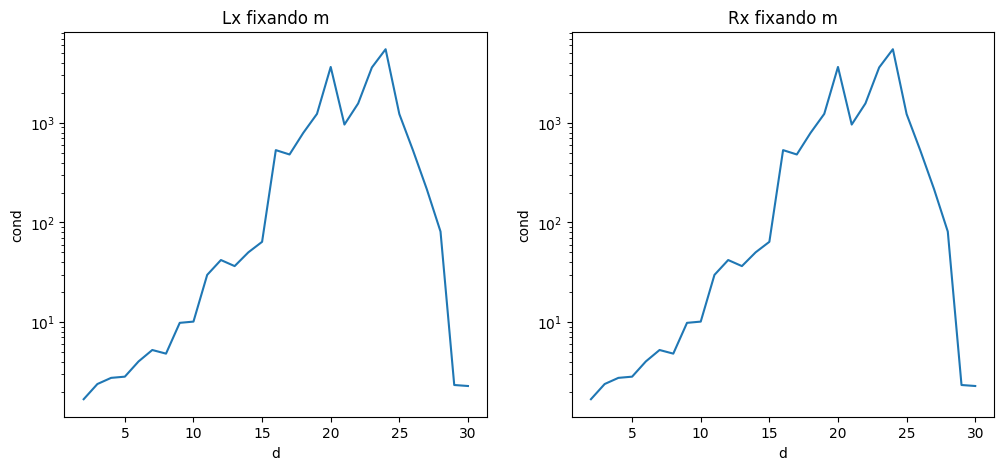

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

lagrange_Lx_test_fixing_m(30, ax=ax1)
ax1.set_title("Lx fixando m")

lagrange_Rx_test_fixing_m(30, ax=ax2)
ax2.set_title("Rx fixando m")

Diferente da base canônica, o condicionamento das matrizes $L_X$ e $R_{X,d}$ diminui drasticamente quando $m=d+1$, pois nesse caso essas matrizes são a identidade, e portanto $\kappa (L_X) = \kappa (R_{X,d}) = 1$

Text(0.5, 1.0, 'Rx fixando d')

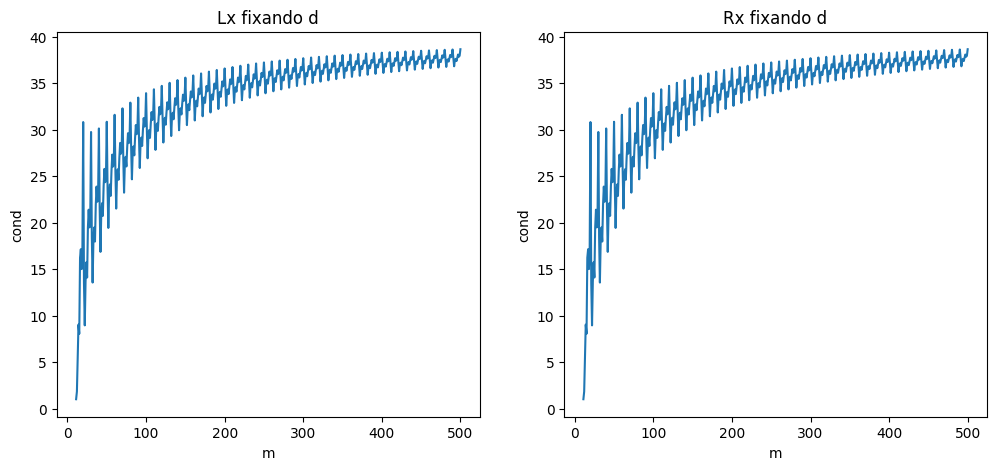

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

lagrange_Lx_test_fixing_d(10, 500, ax=ax1)
ax1.set_title("Lx fixando d")

lagrange_Rx_test_fixing_d(10, 500, ax=ax2)
ax2.set_title("Rx fixando d")

Diferente da base canônica, aqui aumentar o número de pontos aumenta o condicionamento, porém esse aumento diminui cada vez mais, e o condicionamento nesse caso nunca ultrapassa o da base canônica, como veremos adiante.

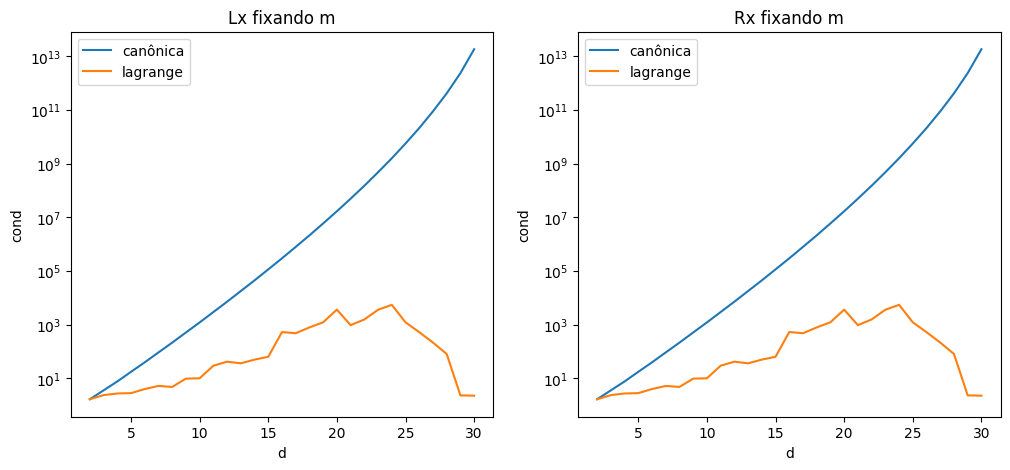

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

canonic_Lx_test_fixing_m(30, ax=ax1)
lagrange_Lx_test_fixing_m(30, ax=ax1)
ax1.set_title("Lx fixando m")
ax1.legend()

canonic_Rx_test_fixing_m(30, ax=ax2)
lagrange_Rx_test_fixing_m(30, ax=ax2)
ax2.set_title("Rx fixando m")
ax2.legend()

Podemos ver aqui que a base de lagrange é muito melhor condicionada que a base canônica.

Enquanto o condicionamento da base de lagrange alcança no máximo $10^3$ o condicionamento da canônica cresce muito mais rápido, e não diminui em nenhum momento.

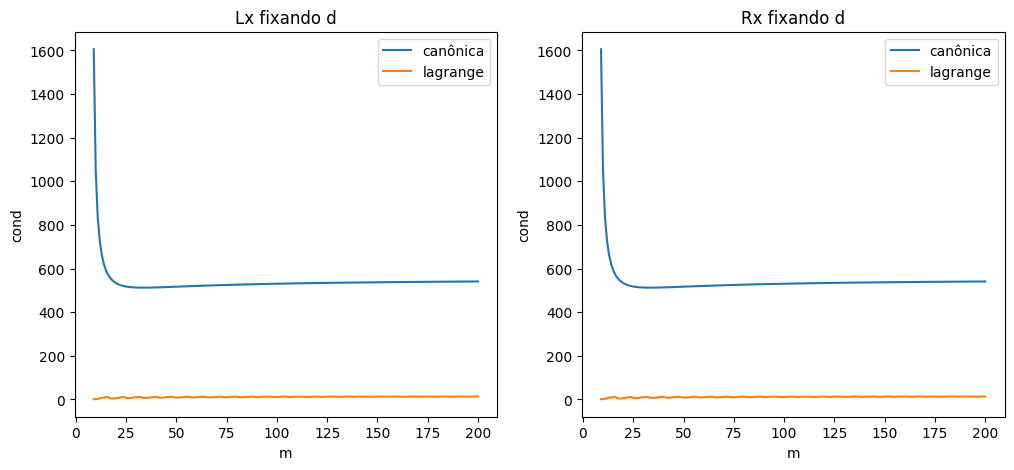

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

canonic_Lx_test_fixing_d(8, 200, ax=ax1)
lagrange_Lx_test_fixing_d(8, 200, ax=ax1)
ax1.set_title("Lx fixando d")
ax1.legend()

canonic_Rx_test_fixing_d(8, 200, ax=ax2)
lagrange_Rx_test_fixing_d(8, 200, ax=ax2)
ax2.set_title("Rx fixando d")
ax2.legend()

Esse gráfico comprova o que tinhamos dito anteriormente, que apesar de aumentar o condicionamento da base de lagrange nunca ultrapassa o da canônica.

### 2. f

Segue abaixo a tabela com o custo computacional de calcular as matrizes $L_X$ e $R_{X,d}$ nas bases canônica e de lagrange.

| Base     | $L_X$         | $R_{X,d}$ |
|----------|---------------|-----------|
| Canônica | $O(md)$       | $O(md^2)$ |
| Lagrange | $O(d^3 + md)$ | $O(md^2)$ |

Podemos reparar que o condicionamento de ambas as matrizes é muito melhor na base de lagrange

É fácil ver que $R_{X,d}$ é melhor na base de lagrange visto que a complexidade de caluclar na base de lagrange ou na canônica é a mesma, a dúvida é sobre usar $L_X$ na base canônica ou de Lagrange.

No entanto é fácil perceber que a matriz $L_X$ é muito melhor condicionada na base dos polinômios de lagrange.

Como podemos ver no gráfico fixando m, a matriz de $L_X$ na base de lagrange fica entre $1 - 10^3$ para $m = 30$ enquanto a canônica explode pra $10^{13}$, não só isso o condicionamento na base de lagrange cai pra $1$ quando $m=d+1$, o que é muito bom.

No gráfico fixando d também é fácil ver que o condicionamento da matriz na base de lagrange é muito melhor.

Portanto concluímos que o condicionamento incrivelmente melhor de $L_X$ na base de lagrange faz valer a pena o custo de calcular os polinômios.

É importante notar que essa melhora só acontece se escolhermos os polinômios para pontos igualmente espaçados em X.

Se simplesmente usarmos os $d+1$ primeiros pontos de X o condicionamento das matrizes na base de Lagrange fica muito pior que na base canônica.

# Questão 3

### 3. a

Sabemos que $R_{X,d}$ é sobrejetora, pois para todo polônimio $p \in P_d$ existe o vetor $b = L_X(p)$ tal que $R_{X,d}(b) = p$.

Seja $T = L_{Y} \circ R_{X,d}$. Como $R_{X,d}$ é sobrejetora $\text{Im}(T) = \text{Im}(L_Y)$

Consequentemente, $$R(T) = \text{dim}(\text{Im}(T) = \text{dim}(\text{Im}(L_Y) = R(L_Y)$$

Como vimos na questão 1.e, $$R(L_Y) = \text{min}(n,d+1) \Rightarrow R(T) = R(L_Y) = \text{min}(n,d+1) $$

In [5]:
d = 5
m = 10
n = 8

X = np.linspace(-1, 1, m)
Y = np.linspace(-1, 1, n)

V_X = np.vander(X, d+1, increasing=True)  

R = np.linalg.pinv(V_X)  

V_Y = np.vander(Y, d+1, increasing=True)  

M = V_Y @ R

print(f"n = {n}")
print(f"d+1 = {d+1}")
print(f"Posto de L_Y ∘ R_{{X,d}}: {np.linalg.matrix_rank(M)}")

d = 6
m = 10
n = 5

X = np.linspace(-1, 1, m)
Y = np.linspace(-1, 1, n)

V_X = np.vander(X, d+1, increasing=True)  

R = np.linalg.pinv(V_X)  

V_Y = np.vander(Y, d+1, increasing=True)  

M = V_Y @ R

print(f"n = {n}")
print(f"d+1 = {d+1}")
print(f"Posto de L_Y ∘ R_{{X,d}}: {np.linalg.matrix_rank(M)}")

n = 8
d+1 = 6
Posto de L_Y ∘ R_{X,d}: 6
n = 5
d+1 = 7
Posto de L_Y ∘ R_{X,d}: 5


### 3. b

A composição $L_Y \circ R_{X,d} : \mathbb{R}^m \rightarrow \mathbb{R}^n$ tem domínio $\mathbb{R}^m$ e contradomínio $\mathbb{R}^n$. O espaço $P_d$ aparece apenas como espaço intermediário, e a escolha de base nele afeta as matrizes de $R_{X,d}$ e $L_Y$ separadamente. Porém, se $P$ é a matriz de mudança de base entre duas bases $B_1$ e $B_2$ de $P_d$, então: $$[L_Y]_{B_1} \cdot [R_{X,d}]_{B_1} = [L_Y]_{B_2}\cdot P \cdot P^{-1} \cdot [R_{X,d}]_{B_2} = [L_Y]_{B_2} \cdot [R_{X,d}]_{B_2}$$

As matrizes de mudança de base se cancelam, e o produto final é o mesmo independentemente da base escolhida. Isso faz sentido pois a composição é uma transformação linear de $\mathbb{R}^m$ em $\mathbb{R}^n$, e sua ação não depende de como representamos o espaço intermediário $P_d$.

### 3. c

Pela questão 2.a, se $b = L_X(q)$ para algum $q \in P_d$, então $R_{X,d}(b) = q$, e portanto $L_Y \circ R_{X,d}(b) = L_Y(q)$, ou seja, os valores exatos de $q$ nos pontos de $Y$.

Nesse sentido, a composta interpola: a partir dos valores de um polinômio de grau $d$ em $m$ pontos de $X$, recupera exatamente os seus valores em $n$ pontos de $Y$.

### 3. d

In [ ]:
def lagrange_L_Y(X, Y, d):
    basis = lagrange_basis(X, d)  
    m = len(Y)
    M = np.zeros((m, d+1))
    for j in range(d+1):
        for i in range(m):
            M[i, j] = basis[j](Y[i])  
    return M

In [ ]:
def eigenvalues_printer(m,n,d):
    X = np.linspace(-1, 1, m)
    Y = np.linspace(-1, 1, n)

    V_X = np.vander(X, N=d+1, increasing=True)
    R_X = np.linalg.pinv(V_X)
    V_Y = np.vander(Y, N=d+1, increasing=True)
    composta_canonica = V_Y @ R_X

    L_X = lagrange_L_X(X, d)
    R_X_lag = np.linalg.pinv(L_X)
    L_Y = lagrange_L_Y(X, Y, d)
    composta_lagrange = L_Y @ R_X_lag

    print("Autovalores da base canônica:")
    print(np.linalg.svd(composta_canonica, compute_uv=False))
    print("")
    print("Autovalores da base de Lagrange:")
    print(np.linalg.svd(composta_lagrange, compute_uv=False))
    print("")
    print(f"Matrizes são iguais: {np.allclose(composta_canonica, composta_lagrange)}")
    print("_____________________________________________________________")

eigenvalues_printer(10,8,5)
eigenvalues_printer(20,10,8)
eigenvalues_printer(5,10,4)


Autovalores da base canônica:
[1.00133211e+00 9.94117132e-01 8.82922511e-01 8.81993320e-01
 8.61640173e-01 8.12225213e-01 1.76366757e-16 8.30895576e-17]

Autovalores da base de Lagrange:
[1.00133211e+00 9.94117132e-01 8.82922511e-01 8.81993320e-01
 8.61640173e-01 8.12225213e-01 8.10641780e-17 5.08537680e-17]

Matrizes são iguais: True
_____________________________________________________________
Autovalores da base canônica:
[9.99093981e-01 9.96697757e-01 7.25065329e-01 6.97732516e-01
 6.88248055e-01 6.88187998e-01 6.87656729e-01 4.69129171e-01
 2.90712787e-01 1.54608289e-16]

Autovalores da base de Lagrange:
[9.99093981e-01 9.96697757e-01 7.25065329e-01 6.97732516e-01
 6.88248055e-01 6.88187998e-01 6.87656729e-01 4.69129171e-01
 2.90712787e-01 1.19281509e-16]

Matrizes são iguais: True
_____________________________________________________________
Autovalores da base canônica:
[1.99179423 1.57843252 1.49682774 1.03988312 1.00458936]

Autovalores da base de Lagrange:
[1.99179423 1.57843

### 3. e

A composição $L_Y \circ R_{X,d}:\mathbb{R}^m \rightarrow \mathbb{R}^n$ pode ser entendida como: dado $b \in \mathbb{R}^m$, encontra o polinômio $p \in P_d$ que melhor se ajusta aos dados e avalia $p$ nos $n$ pontos de $Y$. O condicionamento dessa composição mede o quanto erros em $b$ se amplificam no resultado.

Quando $n \rightarrow \infty$ com $d$ fixo, estamos apenas avaliando o mesmo polinômio $p \in P_d$ em mais pontos. Como $p$ é determinado apenas por $m$ e $d$, adicionar mais pontos de avaliação não altera o polinômio encontrado. O condicionamento não é prejudicado com $n \rightarrow \infty$.

Quando $d$ também cresce, a situação muda, polinômios de grau alto são numericamente instáveis, e o condicionamento explode.  

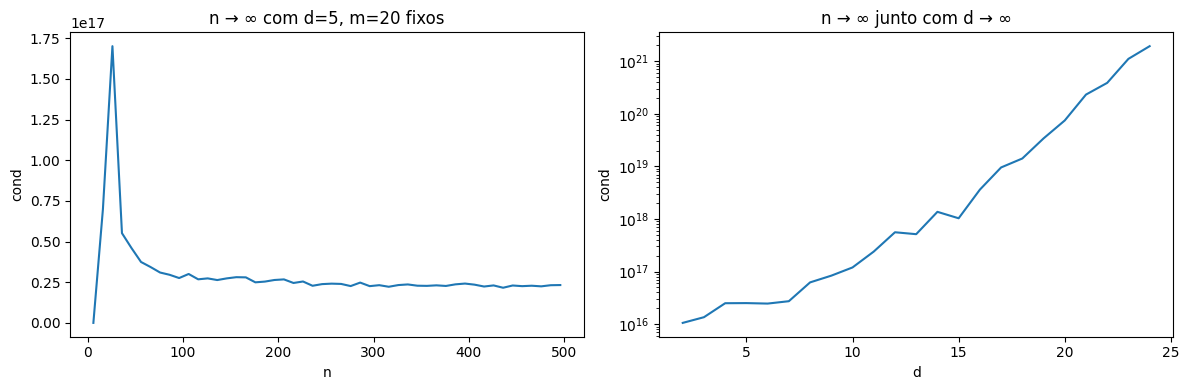

In [ ]:
def composicao(m, n, d):
    X = np.linspace(-1, 1, m)
    Y = np.linspace(-1, 1, n)
    Ly = lagrange_L_X(Y, d)
    Rx = lagrange_R_Xd(X, d)
    return Ly @ Rx

d = 5
m = 20
ns = range(d+1, 500, 10)
conds = [np.linalg.cond(composicao(m, n, d)) for n in ns]
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(list(ns), conds)
plt.xlabel("n")
plt.ylabel("cond")
plt.title(f"n → ∞ com d={d}, m={m} fixos")

m = 100
ds = range(2, 80)
conds2 = [np.linalg.cond(composicao(m, 10*d, d)) for d in ds]
plt.subplot(1, 2, 2)
plt.plot(list(ds), conds2)
plt.xlabel("d")
plt.ylabel("cond")
plt.title("n=10d → ∞ junto com d → ∞")
plt.yscale("log")
plt.tight_layout()
plt.savefig("cond_composicao.png", dpi=150)
plt.show()

##### Primeiro gráfico:

O condicionamento começa alto $n$ pequeno, cai rapidamente e se estabiliza em torno de um valor constante conforme $n$ cresce. Isso confirma o fato de que aumentar $n$ com $d$ fixo não prejudica o condicionamento da composta.

##### Segundo gráfico:

O condicionamento cresce com $d$, confirmando que é o crescimento de $d$ e não de $n$, o responsável pelo aumento do condicionamento. Polinômios de grau alto com pontos igualmente espaçados são instáveis, e o problema se torna cada vez mais sensível a perturbações conforme $d$ cresce, independentemente de quantos pontos de avaliação $n$ sejam usados.

### 3. f

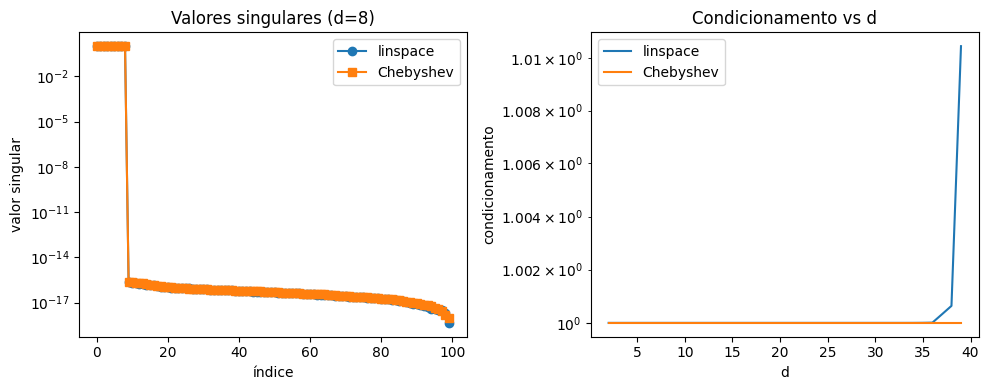

In [ ]:
def chebyshev_points(m):
    i = np.arange(1, m+1)
    return np.cos((2*i - 1) / (2*m)*np.pi)

def lagrange_basis_cheb(X_nodes):
    d = len(X_nodes) - 1
    basis = []
    for i in range(d+1):
        p = np.poly1d([1])
        for j in range(d+1):
            if j != i:
                p *= np.poly1d([1, -X_nodes[j]]) / (X_nodes[i] - X_nodes[j])
        basis.append(p)
    return basis

def lagrange_L_X_cheb(X, X_nodes):
    m = len(X)
    d = len(X_nodes) - 1
    basis = lagrange_basis_cheb(X_nodes)
    M = np.zeros((m, d+1))
    for j in range(d+1):
        for i in range(m):
            M[i,j] = basis[j](X[i])
    return M

def composicao_cheb(m, n, d):
    X_eval = np.linspace(-1, 1, m)        
    Y = np.linspace(-1, 1, n)            
    X_nodes = chebyshev_points(d+1)
    Ly = lagrange_L_X_cheb(Y, X_nodes)
    Lx = lagrange_L_X_cheb(X_eval, X_nodes)
    Rx = np.linalg.pinv(Lx)
    return Ly @ Rx

m, n, d = 100, 100, 8
X_lin = np.linspace(-1, 1, m)
X_nodes_lin = np.linspace(-1, 1, d+1)
Y = np.linspace(-1, 1, n)
Ly_lin = lagrange_L_X_cheb(Y, X_nodes_lin)
Lx_lin = lagrange_L_X_cheb(X_lin, X_nodes_lin)
M_lin = Ly_lin @ np.linalg.pinv(Lx_lin)
M_cheb = composicao_cheb(m, n, d)
sv_lin = np.linalg.svd(M_lin, compute_uv=False)
sv_cheb = np.linalg.svd(M_cheb, compute_uv=False)

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
plt.semilogy(sv_lin, 'o-', label='linspace')
plt.semilogy(sv_cheb, 's-', label='Chebyshev')
plt.xlabel("índice")
plt.ylabel("valor singular")
plt.title("Valores singulares (d=8)")
plt.legend()


plt.subplot(1,2,2)
ds = range(2, 40)
conds_lin, conds_cheb = [], []
for d in ds:
    M_l = lagrange_L_X_cheb(Y, np.linspace(-1,1,d+1)) @ np.linalg.pinv(lagrange_L_X_cheb(X_lin, np.linspace(-1,1,d+1)))
    M_c = composicao_cheb(m, n, d)
    s_lin = np.linalg.svd(M_l, compute_uv=False)
    s_lin = s_lin[s_lin > s_lin[0] * 1e-10]
    conds_lin.append(s_lin[0] / s_lin[-1])

    s_cheb = np.linalg.svd(M_c, compute_uv=False)
    s_cheb = s_cheb[s_cheb > s_cheb[0] * 1e-10]
    conds_cheb.append(s_cheb[0] / s_cheb[-1])

plt.semilogy(list(ds), conds_lin, label='linspace')
plt.semilogy(list(ds), conds_cheb, label='Chebyshev')
plt.xlabel("d")
plt.ylabel("condicionamento")
plt.title("Condicionamento vs d")
plt.legend()
plt.tight_layout()
plt.show()



##### Primeiro gráfico:
A composta $L_Y \circ R_{X,d}$ tem exatamente $d+1=9$ valores singulares significativos, e os restantes caem para praticamente $0$. Isso confirma que o posto da composta é $d+1$, independentemente de $m$ e $n$, e que linspace e Chebyshev produzem a mesma matriz para a composta.

##### Segundo gráfico:
Para $d$ pequeno, o condicionamento da composta é próximo de $1$ para ambas as escolhas de nós, indicando que o problema é bem condicionado. Conforme d cresce, o linspace começa a explodir primeiro, enquanto Chebyshev se mantém estável por mais tempo.

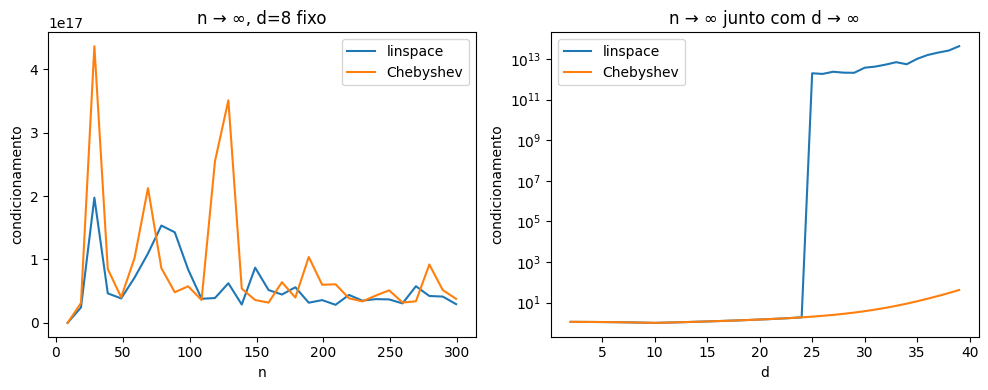

In [ ]:
# Experimento 2: n → ∞
d = 8
m = 30
ns = range(d+1, 300, 10)
conds_n_lin, conds_n_cheb = [], []
for n in ns:
    Y = np.linspace(-1, 1, n)
    M_l = lagrange_L_X_cheb(Y, np.linspace(-1,1,d+1)) @ np.linalg.pinv(lagrange_L_X_cheb(np.linspace(-1,1,m), np.linspace(-1,1,d+1)))
    M_c = composicao_cheb(m, n, d)
    conds_n_lin.append(np.linalg.cond(M_l))
    conds_n_cheb.append(np.linalg.cond(M_c))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(list(ns), conds_n_lin, label='linspace')
plt.plot(list(ns), conds_n_cheb, label='Chebyshev')
plt.xlabel("n")
plt.ylabel("condicionamento")
plt.title(f"n → ∞, d={d} fixo")
plt.legend()

# Experimento 2: n e d → ∞
m = 100
ds = range(2, 40)
conds_nd_lin, conds_nd_cheb = [], []
for d in ds:
    n = 10*d
    Y = np.linspace(-1, 1, n)
    M_l = lagrange_L_X_cheb(Y, np.linspace(-1,1,d+1)) @ np.linalg.pinv(lagrange_L_X_cheb(np.linspace(-1,1,m), np.linspace(-1,1,d+1)))
    M_c = composicao_cheb(m, n, d)

    s_cheb = np.linalg.svd(M_c, compute_uv=False)
    s_cheb = s_cheb[s_cheb > 1e-12]
    if len(s_cheb) > 0:
        conds_nd_cheb.append(s_cheb[0] / s_cheb[-1])
    else:
        conds_nd_cheb.append(np.nan)

    s_lin = np.linalg.svd(M_l, compute_uv=False)
    s_lin = s_lin[s_lin > 1e-12]
    if len(s_lin) > 0:
        conds_nd_lin.append(s_lin[0] / s_lin[-1])
    else:
        conds_nd_lin.append(np.nan)

    conds_lin.append(s_lin[0] / s_lin[-1])
    conds_cheb.append(s_cheb[0] / s_cheb[-1])

plt.subplot(1,2,2)
plt.semilogy(list(ds), conds_nd_lin, label='linspace')
plt.semilogy(list(ds), conds_nd_cheb, label='Chebyshev')
plt.xlabel("d")
plt.ylabel("condicionamento")
plt.title("n → ∞ junto com d → ∞")
plt.legend()
plt.tight_layout()
plt.show()

##### Primeiro gráfico:
O condicionamento permanece baixo e estável conforme $n$ cresce, com apenas pequenas oscilações para $n$ muito pequeno. Isso confirma o fato de que aumentar $n$ com $d$ fixo não prejudica o condicionamento da composta.

##### Segundo gráfico:
Quando $d$ cresce junto com $n$, o linspace tem condicionamento que explode para $10^{13}$, enquanto Chebyshev cresce muito mais devagar, ficando na casa de $10^1$. Isso demonstra claramente a superioridade dos pontos de Chebyshev para interpolação de alto grau.

### 3. g


Agora $Y = linspace(-1.5, 1.5, n)$, ou seja, os pontos de avaliação saem do intervalo $[-1, 1]$ onde os dados foram coletados. Isso é extrapolação, estamos pedindo ao polinômio que preveja valores fora do intervalo de treinamento. 

$R_{X,d}$ continua encontrando o mesmo polinômio $p \in P_d$ ajustando nos pontos de $X \subset [-1, 1]$. Mas agora $L_Y$ avalia pontos fora de $[-1, 1]$, fazendo o condicionamento piorar, pois pequenos erros nos dados de entrada se amplificam mais quando extrapolamos.

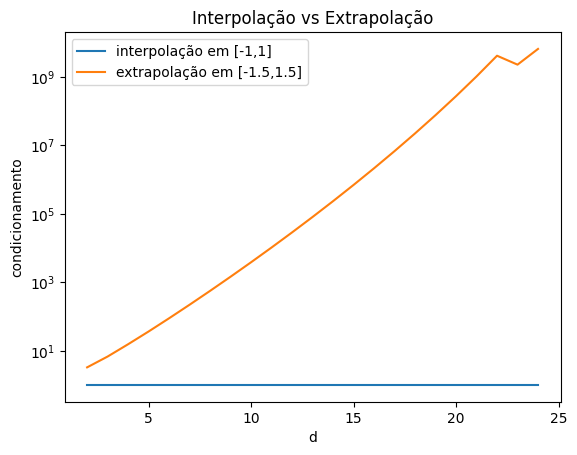

In [ ]:
def composicao_extrap(m, n, d):
    X = np.linspace(-1, 1, m)
    Y = np.linspace(-1.5, 1.5, n)   
    Ly = lagrange_L_X_cheb(Y, np.linspace(-1, 1, d+1))
    Lx = lagrange_L_X_cheb(X, np.linspace(-1, 1, d+1))
    Rx = np.linalg.pinv(Lx)
    return Ly @ Rx

m = 30
ds = range(2, 25)
conds_interp, conds_extrap = [], []
for d in ds:
    M_i = composicao_cheb(m, m, d)        
    M_e = composicao_extrap(m, m, d)      
    s_i = np.linalg.svd(M_i, compute_uv=False)
    s_e = np.linalg.svd(M_e, compute_uv=False)
    s_i = s_i[s_i > s_i[0] * 1e-10]
    s_e = s_e[s_e > s_e[0] * 1e-10]
    conds_interp.append(s_i[0] / s_i[-1])
    conds_extrap.append(s_e[0] / s_e[-1])

plt.semilogy(list(ds), conds_interp, label='interpolação em [-1,1]')
plt.semilogy(list(ds), conds_extrap, label='extrapolação em [-1.5,1.5]')
plt.xlabel("d")
plt.ylabel("condicionamento")
plt.title("Interpolação vs Extrapolação")
plt.legend()
plt.show()

O gráfico mostra que o condicionamento da extrapolação cresce com $d$, chegando a $10^9$, enquanto o da interpolação permanece próximo de 1. Isso acontece porque polinômios de alto grau oscilam muito fora do intervalo de dados, amplificando qualquer erro na entrada.

### 3. h

Os pontos de Chebyshev ajudam porque minimizam as oscilações do polinômio interpolador dentro do intervalo $[−1,1]$. Mas quando extrapolamos para fora desse intervalo, essa vantagem se perde, qualquer polinômio de alto grau oscila bastante fora do intervalo, independentemente de como foram escolhidos os nós de interpolação.

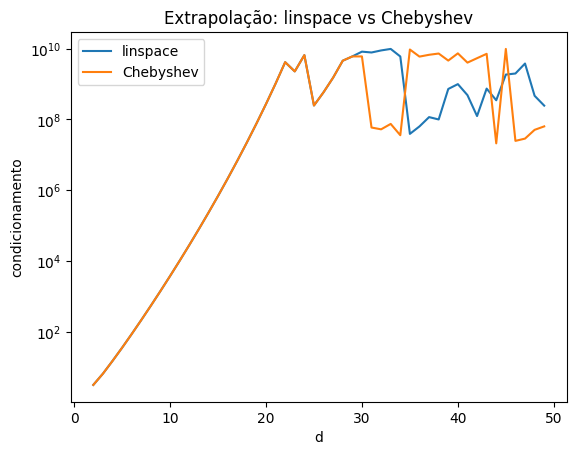

In [ ]:
ds = range(2, 50)
conds_lin_extrap, conds_cheb_extrap = [], []

for d in ds:
    M_lin = lagrange_L_X_cheb(np.linspace(-1.5, 1.5, m), np.linspace(-1, 1, d+1)) @ np.linalg.pinv(lagrange_L_X_cheb(np.linspace(-1, 1, m), np.linspace(-1, 1, d+1)))
    M_cheb = lagrange_L_X_cheb(np.linspace(-1.5, 1.5, m), chebyshev_points(d+1)) @ np.linalg.pinv(lagrange_L_X_cheb(np.linspace(-1, 1, m), chebyshev_points(d+1)))
    s_lin = np.linalg.svd(M_lin, compute_uv=False)
    s_cheb = np.linalg.svd(M_cheb, compute_uv=False)
    s_lin = s_lin[s_lin > s_lin[0] * 1e-10]
    s_cheb = s_cheb[s_cheb > s_cheb[0] * 1e-10]
    conds_lin_extrap.append(s_lin[0] / s_lin[-1])
    conds_cheb_extrap.append(s_cheb[0] / s_cheb[-1])

plt.semilogy(list(ds), conds_lin_extrap, label='linspace')
plt.semilogy(list(ds), conds_cheb_extrap, label='Chebyshev')
plt.xlabel("d")
plt.ylabel("condicionamento")
plt.title("Extrapolação: linspace vs Chebyshev")
plt.legend()
plt.show()

O gráfico mostra que linspace e Chebyshev produzem condicionamentos bem parecidos quando $Y \not\subset [−1,1]$, e ambos crescem bastante com $d$. Isso confirma que a instabilidade da extrapolação é uma propriedade dos polinômios de alto grau fora do intervalo de dados, a escolha dos nós de interpolação, que foi tão importante para a interpolação, não faz nenhuma diferença quando extrapolamos.

### 3. i


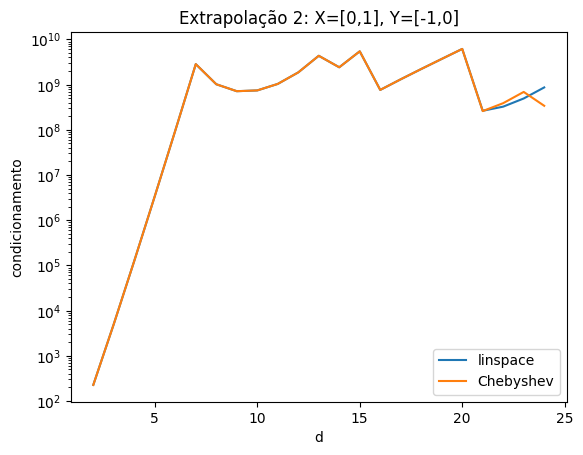

In [ ]:
ds = range(2, 25)
conds_lin, conds_cheb = [], []

for d in ds:
    X = np.linspace(0, 1, m)
    Y = np.linspace(-1, 0, m)
    
    X_nodes_lin = np.linspace(0, 1, d+1)
    M_lin = lagrange_L_X_cheb(Y, X_nodes_lin) @ np.linalg.pinv(lagrange_L_X_cheb(X, X_nodes_lin))
    X_nodes_cheb = 0.5 * (chebyshev_points(d+1) + 1)  # mapeia [-1,1] para [0,1]
    M_cheb = lagrange_L_X_cheb(Y, X_nodes_cheb) @ np.linalg.pinv(lagrange_L_X_cheb(X, X_nodes_cheb))
    
    s_lin = np.linalg.svd(M_lin, compute_uv=False)
    s_cheb = np.linalg.svd(M_cheb, compute_uv=False)
    s_lin = s_lin[s_lin > s_lin[0] * 1e-10]
    s_cheb = s_cheb[s_cheb > s_cheb[0] * 1e-10]
    
    conds_lin.append(s_lin[0] / s_lin[-1])
    conds_cheb.append(s_cheb[0] / s_cheb[-1])

plt.semilogy(list(ds), conds_lin, label='linspace')
plt.semilogy(list(ds), conds_cheb, label='Chebyshev')
plt.xlabel("d")
plt.ylabel("condicionamento")
plt.title("Extrapolação 2: X=[0,1], Y=[-1,0]")
plt.legend()
plt.show()

No item anterior, $Y$ apenas estendia o intervalo $[-1, 1]$, mas agora $X \subset [0, 1]$ e $Y \subset [-1, 0]$ são intervalos completamente separados. Isso faz o condicionamento piorar muito mais rápido como podemos ver no gráfico e assim como no item anterior, percebemos pelo gráfico também que usar os pontos de Chebyshev não oferece nenhuma vantagem, inclusive o condicionamento é bem parecido com o linspace.